<a href="https://colab.research.google.com/github/Whyawww/Dataset-stroke/blob/main/UAS_4671_BDDM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pyspark

In [ ]:
import urllib.request
import os
url = 'https://raw.githubusercontent.com/Whyawww/Dataset-stroke/refs/heads/main/healthcare-dataset-stroke-data.csv'
filename = 'healthcare-dataset-stroke-data.csv'
urllib.request.urlretrieve(url, filename)

from pyspark.sql import SparkSession
from pyspark.sql.functions import col
spark = SparkSession.builder.appName('Healtcare Dataset Stroke Data').getOrCreate()
df = spark.read.csv(filename, header=True, inferSchema=True)
df.show(10)

+-----+------+----+------------+-------------+------------+-------------+--------------+-----------------+----+---------------+------+
|   id|gender| age|hypertension|heart_disease|ever_married|    work_type|Residence_type|avg_glucose_level| bmi| smoking_status|stroke|
+-----+------+----+------------+-------------+------------+-------------+--------------+-----------------+----+---------------+------+
| 9046|  Male|67.0|           0|            1|         Yes|      Private|         Urban|           228.69|36.6|formerly smoked|     1|
|51676|Female|61.0|           0|            0|         Yes|Self-employed|         Rural|           202.21| N/A|   never smoked|     1|
|31112|  Male|80.0|           0|            1|         Yes|      Private|         Rural|           105.92|32.5|   never smoked|     1|
|60182|Female|49.0|           0|            0|         Yes|      Private|         Urban|           171.23|34.4|         smokes|     1|
| 1665|Female|79.0|           1|            0|         

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when
from pyspark.sql.types import IntegerType, DoubleType
from pyspark.ml.feature import StringIndexer, StandardScaler, VectorAssembler
from pyspark.ml import Pipeline

spark = SparkSession.builder \
    .appName("Stroke Prediction Preprocessing") \
    .config("spark.executor.memory", "2g") \
    .getOrCreate()

In [ ]:
print("Schema Dataset:")
df.printSchema()

Schema Dataset:
root
 |-- id: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- age: double (nullable = true)
 |-- hypertension: integer (nullable = true)
 |-- heart_disease: integer (nullable = true)
 |-- ever_married: string (nullable = true)
 |-- work_type: string (nullable = true)
 |-- Residence_type: string (nullable = true)
 |-- avg_glucose_level: double (nullable = true)
 |-- bmi: string (nullable = true)
 |-- smoking_status: string (nullable = true)
 |-- stroke: integer (nullable = true)



In [ ]:
# Shape DataFrame
def shape(data):
    num_rows=data.count()
    num_columns=len(data.columns)
    return (num_rows, num_columns)

initial_shape=shape(df)
print ("Data Shape: ", shape(df))

Data Shape:  (5110, 12)


In [ ]:
import pandas as pd

pd.DataFrame(df.take(5), columns=df.columns)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,N/A,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24,never smoked,1


In [ ]:
# Mengecek Nilai Null
print("\nCek Missing Values:")
null_counts = {col: df.filter(df[col].isNull()).count() for col in df.columns}

for col, count in null_counts.items():
    print(f"Column '{col}' has {count} null values")


Cek Missing Values:
Column 'id' has 0 null values
Column 'gender' has 0 null values
Column 'age' has 0 null values
Column 'hypertension' has 0 null values
Column 'heart_disease' has 0 null values
Column 'ever_married' has 0 null values
Column 'work_type' has 0 null values
Column 'Residence_type' has 0 null values
Column 'avg_glucose_level' has 0 null values
Column 'bmi' has 0 null values
Column 'smoking_status' has 0 null values
Column 'stroke' has 0 null values


# PREPROCESSING DATA

In [ ]:
from pyspark.sql.functions import sum as _sum, col
# Cek missing values
missing_values = df.select([_sum(col(c).isNull().cast("Int")).alias(c) for c in df.columns])

missing_values.show()

+---+------+---+------------+-------------+------------+---------+--------------+-----------------+---+--------------+------+
| id|gender|age|hypertension|heart_disease|ever_married|work_type|Residence_type|avg_glucose_level|bmi|smoking_status|stroke|
+---+------+---+------------+-------------+------------+---------+--------------+-----------------+---+--------------+------+
|  0|     0|  0|           0|            0|           0|        0|             0|                0|  0|             0|     0|
+---+------+---+------------+-------------+------------+---------+--------------+-----------------+---+--------------+------+



In [ ]:
# Mengatasi Missing Values
from pyspark.sql.types import DoubleType
df = df.withColumn("bmi", df["bmi"].cast(DoubleType()))

median_bmi = df.approxQuantile("bmi", [0.5], 0.25)[0]
df = df.fillna({"bmi": median_bmi})
print(median_bmi)

23.5


In [ ]:
# Encoding Data Kategorikal
categorical_columns = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
indexers = [StringIndexer(inputCol=col, outputCol=col + "_index") for col in categorical_columns]

In [ ]:
# Penyeimbangan Data dengan SMOTE
from imblearn.over_sampling import SMOTE
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Konversi Spark DataFrame ke Pandas DataFrame
df_pandas = df.toPandas()

# Memisahkan fitur (X) dan target (y)
X = df_pandas.drop(['id', 'stroke'], axis=1)
y = df_pandas['stroke']

encoder = LabelEncoder()

for col in X.select_dtypes(include=['object']).columns:
    X[col] = encoder.fit_transform(X[col])

# Terapkan SMOTE untuk menyeimbangkan data
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Konversi kembali ke Pandas DataFrame
df_resampled = pd.DataFrame(X_resampled, columns=X.columns)
df_resampled['stroke'] = y_resampled

# Konversi kembali ke Spark DataFrame
df_balanced = spark.createDataFrame(df_resampled)

# Menampilkan jumlah data setelah penyeimbangan
print("\nJumlah data setelah SMOTE:")
df_balanced.groupBy("stroke").count().show()


Jumlah data setelah SMOTE:
+------+-----+
|stroke|count|
+------+-----+
|     0| 4861|
|     1| 4861|
+------+-----+



In [ ]:
# Normalisasi Data
feature_columns = ['age', 'avg_glucose_level', 'bmi'] + [col + "_index" for col in categorical_columns]
assembler = VectorAssembler(inputCols=feature_columns, outputCol="features")

In [ ]:
# Standardisasi fitur numerik menggunakan StandardScaler
scaler = StandardScaler(inputCol="features", outputCol="scaled_features")

In [ ]:
# Membagi Dataset
train_data, test_data = df.randomSplit([0.8, 0.2], seed=42)

In [ ]:
# Membuat pipeline
pipeline = Pipeline(stages=indexers + [assembler, scaler])
model = pipeline.fit(train_data)

In [ ]:
# Mengaplikasikan pipeline ke dataset
train_data_preprocessed = model.transform(train_data)
test_data_preprocessed = model.transform(test_data)

# Menampilkan data hasil preprocessing
print("Data Training Setelah Preprocessing:")
train_data_preprocessed.select("scaled_features", "stroke").show(5)

Data Training Setelah Preprocessing:
+--------------------+------+
|     scaled_features|stroke|
+--------------------+------+
|[0.74891068847044...|     0|
|[0.57269640883034...|     0|
|(8,[0,1,2,4],[1.8...|     0|
|[1.36566066721081...|     0|
|(8,[0,1,2,7],[1.6...|     0|
+--------------------+------+
only showing top 5 rows



# EXPLORATORY DATA

In [ ]:
# Distribusi Variabel Target (`stroke`)
print("\nDistribusi Target (`stroke`):")
df_balanced.groupBy("stroke").count().show()


Distribusi Target (`stroke`):
+------+-----+
|stroke|count|
+------+-----+
|     0| 4861|
|     1| 4861|
+------+-----+



In [ ]:
# Statistik Deskriptif Fitur Numerik
print("\nStatistik Deskriptif Fitur Numerik:")
df_balanced.describe(['age', 'avg_glucose_level', 'bmi']).show()


Statistik Deskriptif Fitur Numerik:
+-------+------------------+-----------------+------------------+
|summary|               age|avg_glucose_level|               bmi|
+-------+------------------+-----------------+------------------+
|  count|              9722|             9722|              9722|
|   mean| 55.23288354057383|118.8292770409187|28.876336110064052|
| stddev|22.166534164871784| 55.1285235414469| 6.843099416098485|
|    min|              0.08|            55.12|              10.3|
|    max|              82.0|           271.74|              97.6|
+-------+------------------+-----------------+------------------+



In [ ]:
# Pemeriksaan Korelasi Fitur Numerik
from pyspark.sql.functions import corr

print("\nKorelasi antara Fitur Numerik dan Target:")
for col_name in ['age', 'avg_glucose_level', 'bmi']:
    correlation = df_balanced.select(corr(col_name, 'stroke')).collect()[0][0]
    print(f"Korelasi antara {col_name} dan stroke: {correlation:.4f}")


Korelasi antara Fitur Numerik dan Target:
Korelasi antara age dan stroke: 0.5983
Korelasi antara avg_glucose_level dan stroke: 0.2546
Korelasi antara bmi dan stroke: 0.0336


In [ ]:
# Distribusi Fitur Kategorikal
categorical_columns = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
for column in categorical_columns:
    print(f"\nDistribusi Kolom Kategorikal: {column}")
    df_balanced.groupBy(column).count().orderBy('count', ascending=False).show()


Distribusi Kolom Kategorikal: gender
+------+-----+
|gender|count|
+------+-----+
|     0| 6545|
|     1| 3176|
|     2|    1|
+------+-----+


Distribusi Kolom Kategorikal: ever_married
+------------+-----+
|ever_married|count|
+------------+-----+
|           1| 7007|
|           0| 2715|
+------------+-----+


Distribusi Kolom Kategorikal: work_type
+---------+-----+
|work_type|count|
+---------+-----+
|        2| 6117|
|        0| 1240|
|        3| 1211|
|        4|  690|
|        1|  464|
+---------+-----+


Distribusi Kolom Kategorikal: Residence_type
+--------------+-----+
|Residence_type|count|
+--------------+-----+
|             0| 5782|
|             1| 3940|
+--------------+-----+


Distribusi Kolom Kategorikal: smoking_status
+--------------+-----+
|smoking_status|count|
+--------------+-----+
|             2| 3355|
|             1| 2802|
|             0| 2614|
|             3|  951|
+--------------+-----+



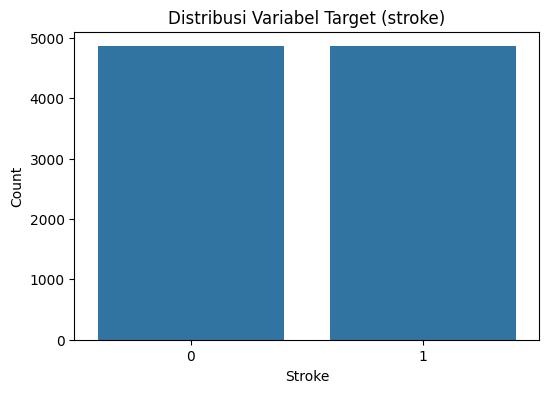

In [ ]:
# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Konversi Spark DataFrame ke Pandas
df_pandas = df_balanced.toPandas()

# Distribusi Target
plt.figure(figsize=(6, 4))
sns.countplot(data=df_pandas, x='stroke')
plt.title("Distribusi Variabel Target (stroke)")
plt.xlabel("Stroke")
plt.ylabel("Count")
plt.show()

Grafik distribusi usia diatas memperlihatkan bahwa pasien yang mengalami stroke lebih banyak berasal dari kelompok usia lanjut.

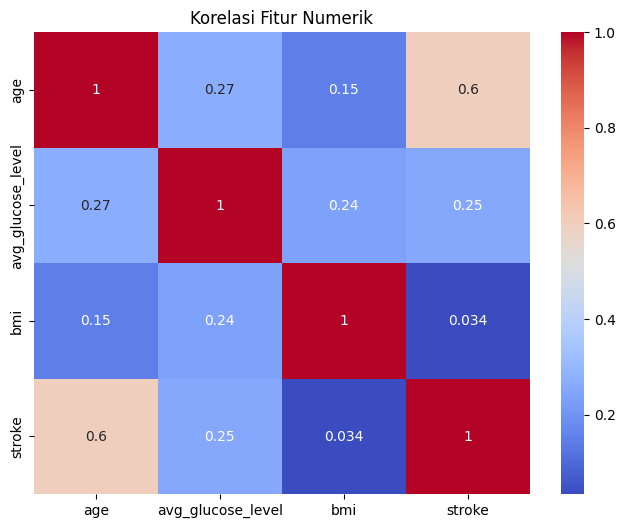

In [ ]:
# Korelasi Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df_pandas[['age', 'avg_glucose_level', 'bmi', 'stroke']].corr(), annot=True, cmap='coolwarm')
plt.title("Korelasi Fitur Numerik")
plt.show()

Heatmap korelasi menunjukkan hubungan yang lemah hingga moderat antara variabel numerik dan target, sehingga model harus mengandalkan kombinasi fitur untuk membuat prediksi.

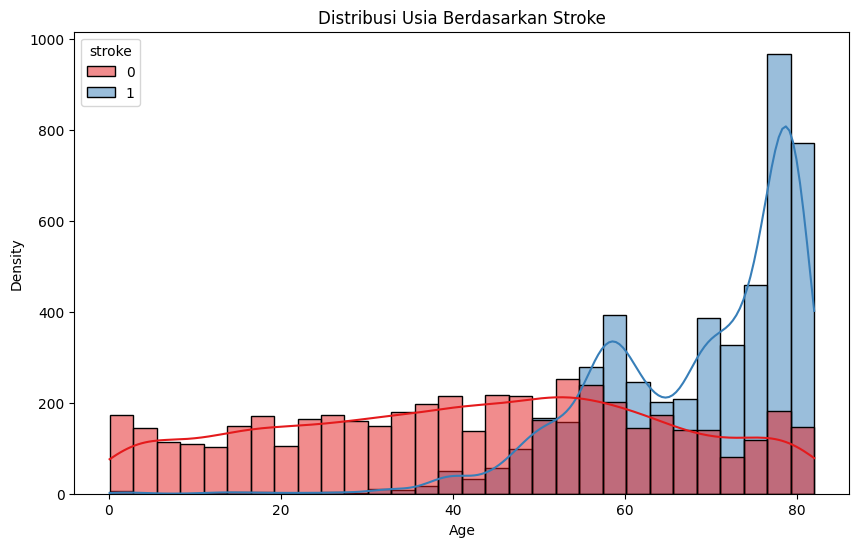

In [ ]:
# Distribusi Usia Berdasarkan Stroke
plt.figure(figsize=(10, 6))
sns.histplot(data=df_pandas, x='age', hue='stroke', kde=True, palette='Set1', bins=30)
plt.title("Distribusi Usia Berdasarkan Stroke")
plt.xlabel("Age")
plt.ylabel("Density")
plt.show()

# Seleksi Fitur

In [ ]:
# Melakukan Seleksi Fitur
from pyspark.ml import Pipeline
indexing_pipeline = Pipeline(stages=indexers)

# Sesuaikan dan ubah pipeline pengindeksan ke df_balanced
df_balanced = indexing_pipeline.fit(df_balanced).transform(df_balanced)

# Menerapkan VectorAssembler
df_features = assembler.transform(df_balanced)

In [ ]:
# Menghitung Mutual Information
from pyspark.ml.stat import ChiSquareTest

chi_square_result = ChiSquareTest.test(df_features, "features", "stroke")
chi_square_result.select("degreesOfFreedom", "pValues", "statistics").show()

+--------------------+--------------------+--------------------+
|    degreesOfFreedom|             pValues|          statistics|
+--------------------+--------------------+--------------------+
|[4267, 8590, 4725...|[0.0,8.4043882964...|[8106.17172534875...|
+--------------------+--------------------+--------------------+



In [ ]:
# Menampilkan Hasil Seleksi Fitur
feature_importance = [(feature, chi_square_result.select("statistics").collect()[0][0][i])
                      for i, feature in enumerate(feature_columns)]

# Mengurutkan berdasarkan skor pentingnya
feature_importance_sorted = sorted(feature_importance, key=lambda x: x[1], reverse=True)
print("\nHasil Seleksi Fitur Berdasarkan Mutual Information (Chi-Square):")
for feature, importance in feature_importance_sorted:
    print(f"Fitur: {feature}, Skor: {importance:.4f}")


Hasil Seleksi Fitur Berdasarkan Mutual Information (Chi-Square):
Fitur: avg_glucose_level, Skor: 9548.0000
Fitur: bmi, Skor: 8448.4666
Fitur: age, Skor: 8106.1717
Fitur: work_type_index, Skor: 1175.3953
Fitur: smoking_status_index, Skor: 873.9778
Fitur: Residence_type_index, Skor: 411.5326
Fitur: gender_index, Skor: 329.6605
Fitur: ever_married_index, Skor: 280.6016


In [ ]:
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.feature import VectorAssembler
from pyspark.ml import Pipeline

# Gunakan fitur terpilih dari seleksi fitur
selected_features = ['age', 'avg_glucose_level', 'bmi', 'ever_married_index', 'smoking_status_index']

assembler = VectorAssembler(inputCols=selected_features, outputCol="features")
data_model = assembler.transform(df_balanced).select("features", "stroke")

In [ ]:
# Split data menjadi training dan testing
train_data, test_data = data_model.randomSplit([0.7, 0.3], seed=42)

# Membuat Model

In [ ]:
# Membuat Model Logistic Regression
lr = LogisticRegression(labelCol="stroke", featuresCol="features", maxIter=20, regParam=0.1, elasticNetParam=0.5)

In [ ]:
# Pipeline untuk training
pipeline = Pipeline(stages=[lr])
model = pipeline.fit(train_data)

In [ ]:
# Prediksi pada data testing
predictions = model.transform(test_data)

# Evaluasi dengan Accuracy, Precision, Recall, F1-Score
evaluator = MulticlassClassificationEvaluator(labelCol="stroke", predictionCol="prediction")

accuracy = evaluator.evaluate(predictions, {evaluator.metricName: "accuracy"})
f1_score = evaluator.evaluate(predictions, {evaluator.metricName: "f1"})

print(f"Accuracy: {accuracy:.4f}")
print(f"F1-Score: {f1_score:.4f}")

Accuracy: 0.7683
F1-Score: 0.7672


In [ ]:
# Prediksi pada Data Testing
predictions = model.transform(test_data)

In [ ]:
# Mengambil label asli, prediksi, dan probabilitas
selected_columns = predictions.select("stroke", "prediction", "probability")

In [ ]:
import os
import pandas as pd

# Konversi ke Pandas untuk memudahkan penyimpanan CSV
pandas_df = selected_columns.toPandas()

# Tentukan path penyimpanan
output_path = "/mnt/data/stroke_predictions.csv"

# Buat direktori jika belum ada
os.makedirs(os.path.dirname(output_path), exist_ok=True)

# Simpan sebagai CSV
pandas_df.to_csv(output_path, index=False)
print(f"Hasil prediksi disimpan dalam format CSV di: {output_path}")

Hasil prediksi disimpan dalam format CSV di: /mnt/data/stroke_predictions.csv


# Evaluasi Model

In [ ]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.sql.functions import col

# Menghitung metrik evaluasi
evaluator = BinaryClassificationEvaluator(labelCol="stroke", rawPredictionCol="probability", metricName="areaUnderROC")
roc_auc = evaluator.evaluate(predictions)

In [ ]:
# Menghitung Precision, Recall, dan F1-Score secara manual
true_positive = predictions.filter((col("stroke") == 1) & (col("prediction") == 1)).count()
false_positive = predictions.filter((col("stroke") == 0) & (col("prediction") == 1)).count()
false_negative = predictions.filter((col("stroke") == 1) & (col("prediction") == 0)).count()
true_negative = predictions.filter((col("stroke") == 0) & (col("prediction") == 0)).count()

In [ ]:
# Precision, Recall, dan F1-Score
precision = true_positive / (true_positive + false_positive) if (true_positive + false_positive) > 0 else 0
recall = true_positive / (true_positive + false_negative) if (true_positive + false_negative) > 0 else 0
f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1_score:.4f}")

ROC-AUC: 0.8378
Precision: 0.7422
Recall: 0.8316
F1-Score: 0.7844
